In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import copy
# initialize the codespace with only A-stabilizer 

def lattice_space(H, L):
    lattice = np.zeros((H, L))
    for i in range(H):
        for j in range(L):
            if i % 3 == 0 and j % 3 != 0:
                lattice[i][j] = 1
            if i % 3 == 1 and j % 3 != 2:
                lattice[i][j] = 1
            if i % 3 == 2 and j % 3 != 1:
                lattice[i][j] = 1
    return lattice
import random

def energy(lattice):
    
    H = lattice.shape[0]
    L = lattice.shape[1]
    energy = np.sum(lattice)  # Total number of spins in state 1
    # for i in range(H):
    #     for j in range(L):
    #         # Periodic boundary conditions
    #         right = lattice[(i+1)% H, (j+1) % L]
    #         down  = lattice[(i+1) % H, j]
    #         energy +=  (lattice[i, j] + right + down)% 2
    return energy

def compute_dE(lattice_, i, j):
    # Sum over four neighbors with periodic boundaries
    E_new = lattice_[i, j] ^ 1  # Flip the spin at (i, j)
    dE = (E_new - lattice_[i, j])
    if dE == 0:
        raise ValueError("No change in energy")
    return dE

def monte_carlo_error(lattice, num_steps, error_rate):
    H = lattice.shape[0]
    L = lattice.shape[1]
    for _ in range(num_steps):
        # i = random.randint(0, H - 1)
        # j = random.randint(0, L - 1)
        # r = random.random()
        # if r < error_rate:
        #     # Flip the qubit
        #     lattice[i, j] = (lattice[i, j] + 1) % 2
            
        for i in range(H):
            for j in range(L):
                r = random.random()
                if r < error_rate:
                    # Flip the qubit
                    lattice[i, j] = (lattice[i, j] + 1) % 2
            

    return lattice
    
def nonzero_random():
    r = random.random()
    while r == 0.0:
        r = random.random()
    return r



def bkl(lattice, steps, error_rate,  configs= None):

    
    if configs     is None: configs     = []
    
    f = 1e-8
    H = lattice.shape[0]
    L = lattice.shape[1]
    time_list = []
    labels = []
    beta = math.log((3+error_rate)/error_rate)/3
    for step in range(steps):
        configs.append(copy.deepcopy(lattice))
        # Create a dictionary to group spin flips by their energy change (dE)
        classes = {0:[] , 1:[]}
        # For each spin, compute its energy change upon flipping
        for i in range(H):
            for j in range(L):
                if lattice[i, j] == 1:
                    classes[1].append((i, j))
                else:
                    classes[0].append((i, j))
        
        # Calculate transition rates for each class:
        # For spins where flipping lowers energy (dE <= 0), acceptance probability is 1;
        # for dE > 0, it is dE*(1-exp(-beta * dE))
        chosen_class = None
        flip = False
        
        #====== p : 1->0, q: 0->1 ======
        p = np.exp(-beta * -1)
        q = np.exp(- beta * 1)
        # p = -1/(1- np.exp(-beta * -1))
        # q = 1/(1-np.exp(- beta * 1))
        prob_flip_1 = len(classes[1])*p
        prob_flip_0 = len(classes[0])*q
        prob_remain_1 = len(classes[1])*(1-p)/(H*L)
        prob_remain_0 = len(classes[0])*(1-q)/(H*L)

        if len(classes[1]) + len(classes[0]) != H*L:
            raise ValueError("Classes do not sum to total number of spins")
        
        total_rate = prob_flip_1 + prob_flip_0
        r = np.random.uniform(0, total_rate)
        if r < prob_flip_1:
            chosen_class = 1
            flip = True
        elif r < prob_flip_1 + prob_flip_0:
            chosen_class = 0
            flip = True
        # elif r < prob_flip_1 + prob_flip_0 + prob_remain_1:
        #     chosen_class = 1
        #     flip = False
        # else:
        #     chosen_class = 0
        #     flip = False
        labels.append(chosen_class)
        if flip:
            i, j = random.choice(classes[chosen_class])
            lattice[i, j] ^= 1 # Flip the spin

        
        # rho3 = nonzero_random()
        rho3 = np.random.uniform(0,1)
        dT = 1/total_rate * -math.log(rho3)
        time_list.append(dT)
        
    return lattice, configs, time_list, labels


def bkl_1(lattice, steps, p, q, configs= None):

    
    if configs     is None: configs     = []
    
    f = 1e-8
    H = lattice.shape[0]
    L = lattice.shape[1]
    time_list = []
    labels = []
    # beta = math.log((3+error_rate)/error_rate)/3
    for step in range(steps):
        # Create a dictionary to group spin flips by their energy change (dE)
        classes = {0:[] , 1:[]}
        # For each spin, compute its energy change upon flipping
        for i in range(H):
            for j in range(L):
                if lattice[i, j] == 1:
                    classes[1].append((i, j))
                else:
                    classes[0].append((i, j))
        
        # Calculate transition rates for each class:
        # For spins where flipping lowers energy (dE <= 0), acceptance probability is 1;
        # for dE > 0, it is dE*(1-exp(-beta * dE))
        chosen_class = None
        flip = False
        
        #====== p : 1->0, q: 0->1 ======
        # p = (-1 / (np.exp(beta * -1)-1 ) )
        # q = (1 / (np.exp(beta * 1)-1 ) )

        prob_flip_1 = len(classes[1])*p/(H*L)
        prob_flip_0 = len(classes[0])*q/(H*L)
        prob_remain_1 = len(classes[1])*(1-p)/(H*L)
        prob_remain_0 = len(classes[0])*(1-q)/(H*L)

        total_rate = prob_flip_1 + prob_flip_0
        r = random.uniform(0, total_rate)
        if r < prob_flip_1:
            chosen_class = 1
            flip = True
        elif r < prob_flip_1 + prob_flip_0:
            chosen_class = 0
            flip = True
        # elif r < prob_flip_1 + prob_flip_0 + prob_remain_1:
        #     chosen_class = 1
        #     flip = False
        # else:
        #     chosen_class = 0
        #     flip = False
        labels.append(chosen_class)
        if flip:
            i, j = random.choice(classes[chosen_class])
            lattice[i, j] ^= 1 # Flip the spin

        configs.append(copy.deepcopy(lattice))
        rho3 = nonzero_random()
        dT = -1/total_rate * math.log(rho3)
        time_list.append(dT)
        
    return lattice, configs, time_list, labels


def _step_fill_uniform_1d(times, values, dt=None, n_steps=None,
                          include_start=True, include_end=False):
    """
    Resample a step function defined by (times, values) onto a uniform grid
    using left-hold (previous value) semantics.

    Parameters
    ----------
    times : 1D array-like, strictly increasing
    values: 1D array-like, same length as `times`
    dt : float, optional
        Target uniform step in physical time. If None, inferred from n_steps.
    n_steps : int, optional
        Number of uniform steps between times[0] and times[-1].
        If provided, dt=(t_end - t_start)/n_steps.
    include_start : bool, default True
        Include the initial time t0 in the output grid.
    include_end : bool, default False
        Include the final time t_end in the output grid.

    Returns
    -------
    t_out, v_out : 1D ndarray
        Uniform grid times and left-hold values.
    """
    t = np.asarray(times, dtype=float)
    v = np.asarray(values, dtype=float)
    if t.ndim != 1 or v.ndim != 1 or len(t) != len(v) or len(t) < 2:
        raise ValueError("times/values must be 1D, same length >=2")
    if not np.all(np.diff(t) > 0):
        raise ValueError("times must be strictly increasing")

    t0, t1 = t[0], t[-1]
    span = t1 - t0
    if span <= 0:
        # Degenerate: all times equal – just return a single sample
        return (np.array([t0]) if include_start else np.array([]),
                np.array([v[0]]) if include_start else np.array([]))

    if dt is None and n_steps is None:
        raise ValueError("Specify either dt or n_steps")
    if dt is None:
        if n_steps <= 0:
            raise ValueError("n_steps must be positive")
        dt = span / n_steps

    # Build the uniform grid
    eps = np.finfo(float).eps * max(1.0, abs(t1))
    start = t0 if include_start else (t0 + dt)
    stop  = (t1 + (eps if include_end else 0.0))
    if start > stop + 1e-15:
        # Nothing to sample
        return np.array([], dtype=float), np.array([], dtype=float)
    t_grid = np.arange(start, stop, dt)
    if include_end and (t_grid.size == 0 or t_grid[-1] < t1 - 0.5*dt):
        # Ensure exact inclusion if requested (avoid FP drift)
        t_grid = np.r_[t_grid, t1]

    # Left-hold: for each grid point τ, pick index i with t[i] <= τ < t[i+1]
    idx = np.searchsorted(t, t_grid, side='right') - 1
    # Clamp to valid range (could be -1 if τ < t0 due to numerical noise)
    idx = np.clip(idx, 0, len(t) - 1)
    v_grid = v[idx]
    return t_grid, v_grid


def step_fill_uniform(times, mags, dt=None, n_steps=None,
                      include_start=False, include_end=False, per_seed=True):
    """
    Batch wrapper. Accepts:
      - a single (times, mags) 1D pair, or
      - lists/arrays of per-realization times and mags (ragged allowed).

    If you pass multiple realizations:
      * If dt is given, that same dt is used for every realization.
      * If n_steps is given and dt is None:
          - per_seed=True  → use each seed's own (t_end - t_start)/n_steps
          - per_seed=False → compute a global dt from the *first* seed's span
                             (or you can change to use global min/max if you prefer).

    Returns
    -------
    T_out, M_out :
        If single trace → (1D t_out, 1D m_out).
        If batch        → (list of 1D arrays t_out_i, list of 1D arrays m_out_i).
    """
    # Detect single vs batch
    def _is_1d_like(x):
        return np.ndim(x) == 1

    # Single trace
    if _is_1d_like(times) and _is_1d_like(mags):
        return _step_fill_uniform_1d(times, mags, dt=dt, n_steps=n_steps,
                                     include_start=include_start, include_end=include_end)

    # Batch: each element of times/mags is a 1D array-like for one realization
    if len(times) != len(mags):
        raise ValueError("For batch input, lengths of times and mags lists must match")

    # Resolve dt per seed if needed
    if dt is not None:
        dts = [float(dt)] * len(times)
    else:
        if n_steps is None:
            raise ValueError("For batch input, specify dt or n_steps")
        if per_seed:
            dts = []
            for ti in times:
                ti = np.asarray(ti, dtype=float)
                if ti.size < 2:
                    raise ValueError("Each seed must have at least 2 timestamps")
                dts.append((ti[-1] - ti[0]) / n_steps)
        else:
            t0 = np.asarray(times[0], dtype=float)
            base_dt = (t0[-1] - t0[0]) / n_steps
            dts = [base_dt] * len(times)

    T_out, M_out = [], []
    for ti, mi, dti in zip(times, mags, dts):
        t_i, m_i = _step_fill_uniform_1d(ti, mi, dt=dti, n_steps=None,
                                         include_start=include_start, include_end=include_end)
        T_out.append(t_i)
        M_out.append(m_i)
    return T_out, M_out


def time_bin(time_lists:list, decoder_mag:list):
    """
    Bins the time lists into intervals of size bin_size.
    Returns a list of binned times and their corresponding counts.
    """
    # flatten cumsum lists in one and divide by equllength bins
    flattened_time = np.concatenate(time_lists)
    flattened_mag = np.concatenate(decoder_mag)

    order_time = np.argsort(np.abs(flattened_time))
    flat_sorted_by_mag_time = flattened_time[order_time]
    flat_sorted_by_mag_mag = flattened_mag[order_time]

    nbins = np.array(time_lists).shape[1]
    edges_time = np.linspace(flat_sorted_by_mag_time.min(), flat_sorted_by_mag_time.max(), nbins+1)
    centers_time = 0.5 * (edges_time[:-1] + edges_time[1:])

    edges_mag = np.linspace(flat_sorted_by_mag_mag.min(), flat_sorted_by_mag_mag.max(), nbins+1)
    centers_mag = 0.5 * (edges_mag[:-1] + edges_mag[1:])

    # create bins 
    bin_idx_1 = np.digitize(flat_sorted_by_mag_time, edges_time) - 1
    bin_idx_1 = np.clip(bin_idx_1, 0, nbins-1)

    sums_time   = np.bincount(bin_idx_1, weights=flat_sorted_by_mag_time, minlength=nbins)
    counts_time = np.bincount(bin_idx_1,           minlength=nbins)

    sums_mag   = np.bincount(bin_idx_1, weights=flat_sorted_by_mag_mag, minlength=nbins)
    counts_mag = np.bincount(bin_idx_1,           minlength=nbins)

    means_time = np.empty_like(centers_time)
    means_mag = np.empty_like(centers_mag)
    # normal division where counts>0
    np.divide(sums_time, counts_time, out=means_time, where=(counts_time>0))
    np.divide(sums_mag, counts_mag, out=means_mag, where=(counts_mag>0))
    # fill empty bins with the bin center
    valid = counts_time > 0
    empty = ~valid
    means_time[empty] = centers_time[empty]

    means_mag[empty]    = np.interp(centers_time[empty],
                                    centers_time[valid], means_mag[valid])
    return means_time,  means_mag


def time_bin_1(time_lists:list, decoder_mag:list):
    """
    Bins the time lists into intervals of size bin_size.
    Returns a list of binned times and their corresponding counts.
    """
    # flatten cumsum lists in one and divide by equllength bins
    N, T = np.array(time_lists).shape
    time_finer = np.zeros((N, (T-1)*10))
    mag_finer = np.zeros((N, (T-1)*10))
    min_t = min([min(np.diff(tl)) for tl in time_lists])
    # for i in range(N):
    #     time_finer[i], mag_finer[i] = step_fill_uniform(time_lists[i], decoder_mag[i], n_steps=(T-1)*10)
    time_finer, mag_finer = step_fill_uniform(time_lists, decoder_mag, n_steps=(T-1)*30)
    flattened_time = np.concatenate(time_finer)
    flattened_mag = np.concatenate(mag_finer)

    order_time = np.argsort(np.abs(flattened_time))
    flat_sorted_by_mag_time = flattened_time[order_time]
    flat_sorted_by_mag_mag = flattened_mag[order_time]

    nbins = np.array(time_lists).shape[1]
    edges_time = np.linspace(flat_sorted_by_mag_time.min(), flat_sorted_by_mag_time.max(), nbins+1)
    centers_time = 0.5 * (edges_time[:-1] + edges_time[1:])

    edges_mag = np.linspace(flat_sorted_by_mag_mag.min(), flat_sorted_by_mag_mag.max(), nbins+1)
    centers_mag = 0.5 * (edges_mag[:-1] + edges_mag[1:])

    # create bins 
    bin_idx_1 = np.digitize(flat_sorted_by_mag_time, edges_time) - 1
    bin_idx_1 = np.clip(bin_idx_1, 0, nbins-1)

    sums_time   = np.bincount(bin_idx_1, weights=flat_sorted_by_mag_time, minlength=nbins)
    counts_time = np.bincount(bin_idx_1,           minlength=nbins)

    sums_mag   = np.bincount(bin_idx_1, weights=flat_sorted_by_mag_mag, minlength=nbins)
    counts_mag = np.bincount(bin_idx_1,           minlength=nbins)

    means_time = np.empty_like(centers_time)
    means_mag = np.empty_like(centers_mag)
    # normal division where counts>0
    np.divide(sums_time, counts_time, out=means_time, where=(counts_time>0))
    np.divide(sums_mag, counts_mag, out=means_mag, where=(counts_mag>0))
    # fill empty bins with the bin center
    valid = counts_time > 0
    empty = ~valid
    means_time[empty] = centers_time[empty]

    means_mag[empty]    = np.interp(centers_time[empty],
                                    centers_time[valid], means_mag[valid])
    return means_time,  means_mag

import numpy as np

def time_bin_average_auto(time_lists, energy_lists, extend_right=True, bin_factor=1.0):
    """
    Automatically chooses nbins based on input trajectories, 
    performs left-hold extrapolation, and averages across trajectories.

    Parameters
    ----------
    time_lists : list of 1D arrays/lists
        Uneven time series for each trajectory.
    energy_lists : list of 1D arrays/lists
        Energies at each time point for each trajectory.
    extend_right : bool, default True
        Whether to hold the last energy constant after last recorded time.
    bin_factor : float, default 1.0
        Scaling factor on automatic bin count (e.g. 2.0 doubles resolution).

    Returns
    -------
    edges : 1D ndarray
        Common time edges.
    mean_energy : 1D ndarray
        Average extrapolated energy at each edge.
    std_energy : 1D ndarray
        Standard deviation of energies across trajectories at each edge.
    """
    # --- Step 1: determine bin count automatically ---
    # use mean trajectory length across all time series
    avg_len = np.mean([len(t) for t in time_lists])
    nbins = int(np.round((avg_len - 1) * bin_factor))
    nbins = max(nbins, 5)  # ensure at least a few bins

    # global time span
    tmin = min(t[0] for t in time_lists)
    tmax = max(t[-1] for t in time_lists)
    edges = np.linspace(tmin, tmax, nbins + 1)

    n_traj = len(time_lists)
    n_edges = len(edges)
    all_E = np.full((n_traj, n_edges), np.nan)

    # --- Step 2: per-trajectory left-hold extrapolation ---
    for i, (t, e) in enumerate(zip(time_lists, energy_lists)):
        t = np.asarray(t, float)
        e = np.asarray(e, float)
        idx = np.searchsorted(t, edges, side='right') - 1
        valid = idx >= 0
        if extend_right:
            idx = np.clip(idx, 0, len(t) - 1)
            valid[:] = True
        all_E[i, valid] = e[idx[valid]]

    # --- Step 3: average across trajectories ---
    mean_energy = np.nanmean(all_E, axis=0)
    std_energy  = np.nanstd(all_E, axis=0)

    return edges, mean_energy, std_energy



def plot_lattice(configs:list, time_list:list, title="Spin 1"):
    mags = np.array([np.sum(np.abs(config)) for config in configs])/configs[0].size
    T = np.cumsum(time_list)
    plt.plot(T, mags, 'o-', label ='spins')
    plt.title(title)
    plt.xlabel('time steps')
    plt.ylabel('spin1 fraction')
    plt.show()



def mc_spin_flip(lattice, steps, p, q, *, mode="random_site", configs=None, sample_every=1, rng=None):
    """
    Standard Monte Carlo for independent 0/1 spins with constant flip probs:
      p: prob(1 -> 0) per attempt
      q: prob(0 -> 1) per attempt

    Args
    ----
    lattice : np.ndarray of shape (H, L), integer 0/1
    steps   : int
        If mode="random_site": number of single-spin attempts (each attempt picks a random site).
        If mode="sweep": number of sweeps (each sweep does N attempts in random order).
    p, q    : float in [0,1]
    mode    : "random_site" or "sweep"
    configs : list to append snapshots (deep copies) to; if None, a new list is created
    sample_every : record to `configs` every this many steps (MC steps in chosen mode)
    rng     : np.random.Generator or Python's random; if None, use Python `random`

    Returns
    -------
    lattice_out, configs, time_list
      lattice_out : np.ndarray final configuration
      configs     : list of np.ndarray snapshots
      time_list   : list of float time increments (sum ≈ number of sweeps)
    """
    if configs is None:
        configs = []

    H, L = lattice.shape
    N = H * L
    lat = lattice.astype(np.uint8, copy=False)

    # clamp probabilities to [0,1] defensively
    p = min(max(p, 0.0), 1.0)
    q = min(max(q, 0.0), 1.0)

    # RNG helpers
    if rng is None:
        rand = random.random
        randint = lambda hi: random.randrange(hi)
        shuffle = random.shuffle
    elif isinstance(rng, np.random.Generator):
        rand = rng.random
        randint = rng.integers
        shuffle = lambda seq: rng.shuffle(seq)
    else:
        # assume Python-like API
        rand = rng.random
        randint = lambda hi: rng.randrange(hi)
        shuffle = rng.shuffle

    time_list = []

    if mode == "random_site":
        dt = 1.0 / N
        for t in range(steps):
            i = randint(H)
            j = randint(L)
            if lat[i, j] == 1:
                if rand() < p:
                    lat[i, j] ^= 1  # flip 1->0
            else:
                if rand() < q:
                    lat[i, j] ^= 1  # flip 0->1

            time_list.append(dt)
            if (t + 1) % sample_every == 0:
                configs.append(lat.copy())

    elif mode == "sweep":
        dt = 1.0
        idx = np.arange(N)
        for s in range(steps):
            shuffle(idx)  # random order each sweep
            # visit each site once
            for k in idx:
                i, j = divmod(int(k), L)
                if lat[i, j] == 1:
                    if rand() < p:
                        lat[i, j] ^= 1
                else:
                    if rand() < q:
                        lat[i, j] ^= 1
            time_list.append(dt)
            if (s + 1) % sample_every == 0:
                configs.append(lat.copy())
    else:
        raise ValueError("mode must be 'random_site' or 'sweep'")

    return lat, configs, time_list

In [2]:
def spin_classify(patterns:list, ordering = False):
    flat_each = [ [x for row in m for x in row] for m in patterns ]
    keys = []
    for flat in flat_each:
        bitstr = ''.join('1' if b else '0' for b in flat)
        keys.append(bitstr)
    classes = defaultdict(int)
    for key in keys:
        if key not in classes:
            classes[key] = 0
        classes[key] +=1 
    if ordering == True:
        indices = {}
        for key in keys:
           indices[key]= [i for i, s in enumerate(keys) if s == key]
        return classes, indices
    else:
        return classes

from itertools import product

def all_binary_matrices(n_rows: int, n_cols: int):
    """
    Yield every n_rows x n_cols matrix with entries in {0,1}, row-major order.
    Each matrix is a list of lists of ints.
    Total count: 2**(n_rows * n_cols).
    """
    for bits in product((0, 1), repeat=n_rows * n_cols):
        yield [list(bits[i*n_cols:(i+1)*n_cols]) for i in range(n_rows)]

def decstr_to_bits_width(s: str, width: int, twos_complement: bool = False) -> str:
    n = int(s.strip())
    if n >= 0:
        return format(n, f'0{width}b')[-width:]      # trim if too long
    else:
        # two's complement within given width
        return format((1 << width) + n, f'0{width}b')[-width:]




from collections import Counter
from typing import Iterable, Callable, Any, Optional

def is_subset(
    A: Iterable[Any],
    B: Iterable[Any],
    mode: str = "set",
    key: Optional[Callable[[Any], Any]] = None,
) -> bool:
    """
    Check if A is a 'subset' of B under different notions:

    mode:
      - 'set'        : ignore multiplicities and order (mathematical subset)
      - 'multiset'   : respect multiplicities (bag/multiset subset)
      - 'subsequence': order matters but elements need not be contiguous

    key:
      Optional transformer to make elements hashable/normalized
      (e.g., key=tuple for lists-of-lists; key=str for bitstrings).
    """
    if key is None:
        key = lambda x: x

    if mode == "set":
        try:
            return set(map(key, A)).issubset(set(map(key, B)))
        except TypeError:
            # fallback if elements aren’t hashable: materialize and scan
            A_norm = list(map(key, A))
            B_norm = list(map(key, B))
            return all(x in B_norm for x in A_norm)

    elif mode == "multiset":
        # counts in A must be <= counts in B for every element
        A_cnt = Counter(map(key, A))
        B_cnt = Counter(map(key, B))
        return all(A_cnt[x] <= B_cnt.get(x, 0) for x in A_cnt)

    elif mode == "subsequence":
        # each element of A must appear in B in order (not necessarily contiguously)
        it = iter(map(key, B))
        try:
            return all(next(x for x in it if x == key(a)) or True for a in A)
        except StopIteration:
            return False

    else:
        raise ValueError("mode must be 'set', 'multiset', or 'subsequence'")



In [3]:
def average_on_time_edges_left_hold(t, x, nbins):
    """
    Left-hold average across realizations on common time bin edges.

    Parameters
    ----------
    t : (R, T) array
        Times for each realization. Can include NaNs as padding.
    x : (R, T) array
        Values for each realization. Can include NaNs as padding.
    nbins : int
        Number of uniform bins. Output has nbins+1 edges.

    Returns
    -------
    edges : (nbins+1,) array
        Uniform bin-edge times spanning [global min(t), global max(t)].
    mean : (nbins+1,) array
        Mean across realizations at each edge (NaN-ignored).
    """
    t = np.asarray(t, dtype=float)
    x = np.asarray(x, dtype=float)
    if t.shape != x.shape or t.ndim != 2:
        raise ValueError(f"t and x must be 2D with the same shape. Got t={t.shape}, x={x.shape}")

    t_min = np.nanmin(t)
    t_max = np.nanmax(t)
    if not np.isfinite(t_min) or not np.isfinite(t_max) or t_min == t_max:
        raise ValueError("Invalid global time range (check for NaNs or constant times).")

    edges = np.linspace(t_min, t_max, nbins + 1)

    R, _ = t.shape
    values_on_edges = np.full((R, edges.size), np.nan)

    for i in range(R):
        mask = np.isfinite(t[i]) & np.isfinite(x[i])
        ti = t[i, mask]
        xi = x[i, mask]
        if ti.size == 0:
            continue

        # sort by time
        # order = np.argsort(ti)
        # ti = ti[order]
        # xi = xi[order]

        idx = np.searchsorted(ti, edges, side="right") - 1
        valid = (idx >= 0) & (edges <= ti[-1])
        values_on_edges[i, valid] = xi[idx[valid]]

    mean = np.nanmean(values_on_edges, axis=0)
    return edges, mean


In [4]:
def average_on_time_edges_from_endtimes(t_end, x_interval, nbins, extend_right=False):
    """
    t_end[i,k] = end time of interval k (T_{k+1})
    x_interval[i,k] = value on interval [T_k, T_{k+1})
    """
    t_end = np.asarray(t_end, float)
    x_interval = np.asarray(x_interval, float)
    if t_end.shape != x_interval.shape or t_end.ndim != 2:
        raise ValueError("t_end and x_interval must be 2D with same shape")

    t_min = 0.0
    t_max = np.nanmax(t_end)
    edges = np.linspace(t_min, t_max, nbins + 1)

    R, _ = t_end.shape
    out = np.full((R, edges.size), np.nan)

    for i in range(R):
        mask = np.isfinite(t_end[i]) & np.isfinite(x_interval[i])
        ti = t_end[i, mask]
        xi = x_interval[i, mask]
        if ti.size == 0:
            continue

        # should already be increasing, but safe:
        order = np.argsort(ti)
        ti = ti[order]
        xi = xi[order]

        # interval index k such that edge is inside [T_k, T_{k+1})
        idx = np.searchsorted(ti, edges, side="right")  # NOTE: no "-1"

        if extend_right:
            idx = np.clip(idx, 0, xi.size - 1)
            valid = (idx >= 0)
        else:
            valid = (idx >= 0) & (idx < xi.size) & (edges < ti[-1])

        out[i, valid] = xi[idx[valid]]

    mean = np.nanmean(out, axis=0)
    return edges, mean


/var/folders/b0/yd0t1s1d3csclx8j2np0lfvc0000gn/T/ipykernel_1262/1261048525.py:41: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(out, axis=0)


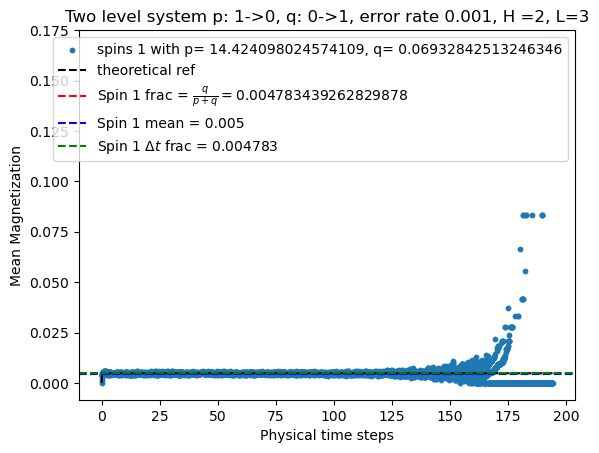

differences between theore and numerical average -0.0001341006304115197
differences between theore and numerical average with time weight -1.0448856152620728e-07


In [29]:
seeds = 6000
steps = 100
error_rate = 0.001
H = 2
L = 3
beta = math.log((3+error_rate)/error_rate)/3
# p = (-1 / (np.exp(beta * -1)-1 ) )
# q = (1 / (np.exp(beta * 1)-1 ) )

p = (np.exp(-beta * -1) )
q = np.exp(-beta * 1)

t_start = 0
t_end = 1
Lattice = np.zeros((H, L), dtype=int)
mag_lists = np.zeros((seeds, steps-t_start))
time_lists = np.zeros((seeds, steps-t_start))
fracs = np.zeros(seeds)



for seed in range(seeds):
    random.seed(seed)
    np.random.seed(seed)
    Lattice = np.zeros((H, L), dtype=int)
    lattice, configs, time_list, labels = bkl(Lattice, steps, error_rate)
    mags = np.array([np.sum(configs[i]) for i in range(t_start, steps )])/configs[0].size
    mag_lists[seed] = mags
    time_lists[seed] = np.cumsum(time_list[t_start:])
    spin_1s = np.where(np.array(labels) == 1)[0]
    total_time = sum(time_list[t_start:-t_end])
    frac = [np.sum(configs[spin_i]) * time_list[spin_i] for spin_i in range(t_start, steps - t_end)]
    fracs[seed] = sum(frac)/(total_time* H * L)

#       time binning
# mean_times, mean_mags, std = time_bin_average_auto(time_lists, mag_lists)
mean_times, mean_mags = average_on_time_edges_from_endtimes(time_lists, mag_lists, nbins=6000)
mag_ref = q/(p+q) - q/(p+q)* np.exp(-(p+q) *mean_times) 
# mean_times, mean_mags = time_bin_1(time_lists, mag_lists)
# mean_times = np.mean(time_lists, axis=0)
# mean_mags = np.mean(mag_lists, axis=0)
mean_mean_mags = np.mean(mean_mags[:-t_end], axis=0)
mean_frac = np.mean(fracs)

#       plotting
# plt.plot(time_lists[0], mag_lists[0], 'o-', label = f'spins 1 with p= {p}, q= {q}')
plt.scatter(mean_times, mean_mags, s=10, label = f'spins 1 with p= {p}, q= {q}')
plt.plot(mean_times, mag_ref, 'k--', label ='theoretical ref')
# plt.errorbar(mean_times, mean_mags, yerr=std, fmt='o', ecolor='gray', alpha=0.)
plt.axhline(y=q/(p+q), color='r', linestyle='--', label =rf'Spin 1 frac = $\frac{{q}}{{p+q}}= {q/(p+q)}$')
# plt.axhline(y=1/(1+np.exp(beta)), color='r', linestyle='--', label =rf'Spin 1 frac = $\frac{{q}}{{p+q}}= {q/(p+q)}$')
plt.axhline(y=mean_mean_mags, color='b', linestyle='--', label =fr'Spin 1 mean = {mean_mean_mags:.3f}')
plt.axhline(y=mean_frac, color='g', linestyle='--', label =fr'Spin 1 $\Delta t$ frac = {mean_frac:.6f}')
plt.title(f'Two level system p: 1->0, q: 0->1, error rate {error_rate}, H ={H}, L={L}')
plt.xlabel('Physical time steps')
plt.ylabel('Mean Magnetization')
# plt.xlim(0, 50)
plt.legend()
plt.show()
print('differences between theore and numerical average', mean_mean_mags - q/(p+q))
print('differences between theore and numerical average with time weight', mean_frac - q/(p+q))

/var/folders/b0/yd0t1s1d3csclx8j2np0lfvc0000gn/T/ipykernel_1262/1261048525.py:41: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(out, axis=0)


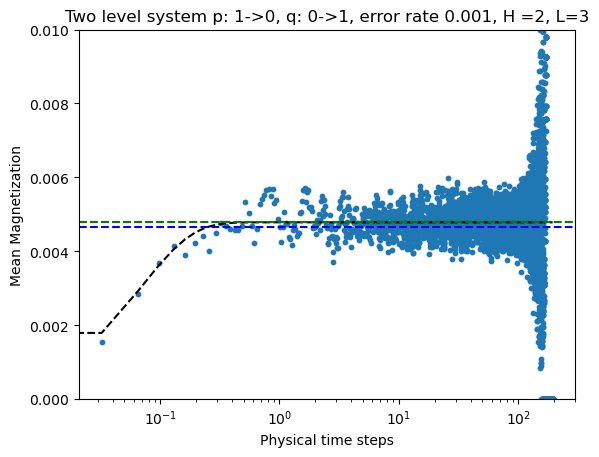

differences between theore and numerical average -0.0001341006304115197
differences between theore and numerical average with time weight -1.0448856152620728e-07


In [33]:
mean_times, mean_mags = average_on_time_edges_from_endtimes(time_lists, mag_lists, nbins=6000)
mag_ref = q/(p+q) - q/(p+q)* np.exp(-(p+q) *mean_times) 
# mean_times, mean_mags = time_bin_1(time_lists, mag_lists)
# mean_times = np.mean(time_lists, axis=0)
# mean_mags = np.mean(mag_lists, axis=0)
mean_mean_mags = np.mean(mean_mags[:-t_end], axis=0)
mean_frac = np.mean(fracs)


plt.scatter(mean_times, mean_mags, s=10, label = f'spins 1 with p= {p}, q= {q}')
plt.plot(mean_times, mag_ref, 'k--', label ='theoretical ref')
# plt.errorbar(mean_times, mean_mags, yerr=std, fmt='o', ecolor='gray', alpha=0.)
plt.axhline(y=q/(p+q), color='r', linestyle='--', label =rf'Spin 1 frac = $\frac{{q}}{{p+q}}= {q/(p+q)}$')
# plt.axhline(y=1/(1+np.exp(beta)), color='r', linestyle='--', label =rf'Spin 1 frac = $\frac{{q}}{{p+q}}= {q/(p+q)}$')
plt.axhline(y=mean_mean_mags, color='b', linestyle='--', label =fr'Spin 1 mean = {mean_mean_mags:.3f}')
plt.axhline(y=mean_frac, color='g', linestyle='--', label =fr'Spin 1 $\Delta t$ frac = {mean_frac:.6f}')
plt.title(f'Two level system p: 1->0, q: 0->1, error rate {error_rate}, H ={H}, L={L}')
plt.xlabel('Physical time steps')
plt.ylabel('Mean Magnetization')
plt.ylim(0, 0.01)
# plt.xlim(0,4)
plt.xscale('log')
# plt.legend()
plt.show()
print('differences between theore and numerical average', mean_mean_mags - q/(p+q))
print('differences between theore and numerical average with time weight', mean_frac - q/(p+q))

In [40]:
print(mean_mags[0])

0.16549999999999987


In [26]:
with open('results.csv', 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['seed', 'mem_time', 'energies', 'mags'])
        for seed, mt, en, mg in zip(seeds, mem_times, energies, mags):
            writer.writerow([
                seed,
                f"{mt:.6f}",
                json.dumps(en),
                json.dumps(mg),
            ])

    print(f"Wrote results.csv with {len(seeds)} rows.")


IndentationError: unindent does not match any outer indentation level (<string>, line 12)

NameError: name 'n' is not defined

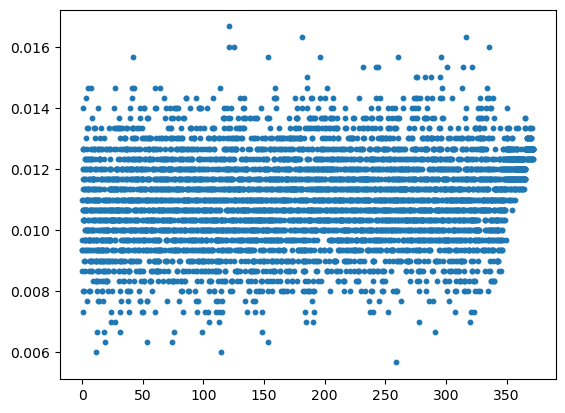

In [124]:

plt.scatter(mean_times, mean_mags, s=10, label = f'spins 1 with p= {p}, q= {q}')
plt.errorbar(mean_times, mean_mags, yerr=std/np.sqrt(n), fmt='.', ecolor='gray', alpha=0.9)
plt.axhline(y=q/(p+q), color='r', linestyle='--', label =rf'Spin 1 frac = $\frac{{q}}{{p+q}}= {q/(p+q)}$')
# plt.axhline(y=1/(1+np.exp(beta)), color='r', linestyle='--', label =rf'Spin 1 frac = $\frac{{q}}{{p+q}}= {q/(p+q)}$')
plt.axhline(y=mean_mean_mags, color='b', linestyle='--', label =fr'Spin 1 mean = {mean_mean_mags:.3f}')
plt.axhline(y=mean_frac, color='g', linestyle='--', label =fr'Spin 1 $\Delta t$ frac = {mean_frac:.6f}')
plt.title(f'Two level system p: 1->0, q: 0->1, error rate {error_rate}, H ={H}, L={L}')
plt.xlabel('Physical time steps')
plt.ylabel('Mean Magnetization')
# plt.xlim(0, 50)
plt.legend()
plt.show()
print('differences between theore and numerical average', mean_mean_mags - q/(p+q))
print('differences between theore and numerical average with time weight', mean_frac - q/(p+q))

[0.09166288 0.09277568 0.09439765 0.09290808 0.09207279 0.09518922
 0.09044046 0.09028926 0.09003863 0.09244926]


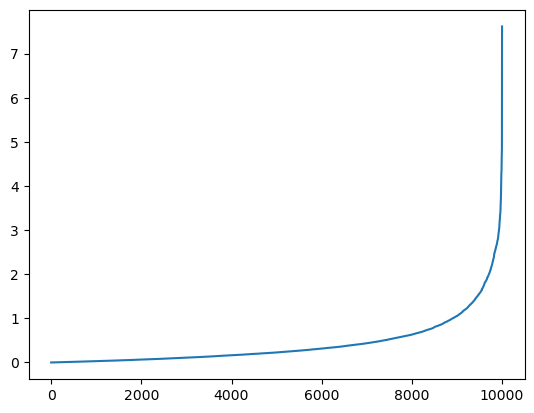

In [7]:
print(fracs)
# print(np.mean(en_lists/6, axis=1))
t = sorted(time_list, key=lambda x: abs(x))
plt.plot(np.arange(len(time_list)), t)
# plt.yscale('log')


In [246]:
print(sum(time_list))
print(time_list[:50])

55804.99910110195
[np.float64(11.157228231595534), np.float64(0.014921351187519902), np.float64(11.157228231595534), np.float64(0.014921351187519902), np.float64(11.157228231595534), np.float64(0.014921351187519902), np.float64(11.157228231595534), np.float64(0.014921351187519902), np.float64(11.157228231595534), np.float64(0.014921351187519902), np.float64(11.157228231595534), np.float64(0.014921351187519902), np.float64(11.157228231595534), np.float64(0.014921351187519902), np.float64(11.157228231595534), np.float64(0.014921351187519902), np.float64(11.157228231595534), np.float64(0.014921351187519902), np.float64(11.157228231595534), np.float64(0.014921351187519902), np.float64(11.157228231595534), np.float64(0.014921351187519902), np.float64(11.157228231595534), np.float64(0.014921351187519902), np.float64(11.157228231595534), np.float64(0.014921351187519902), np.float64(11.157228231595534), np.float64(0.014921351187519902), np.float64(11.157228231595534), np.float64(0.014921351187

In [25]:
%cd /Users/tomarr626/Downloads/
import nbimporter
%run non_interacting_tls.ipynb

error_rate = 0.00001
beta = math.log((3+error_rate)/error_rate)/3
gamma = (np.exp(beta * 1) ) # 1 --> 0
eta = np.exp(beta * -1) # 0 --> 1
np.random.seed(1)

# simulate lattice of non-interacting two-level systems
# dp0/dt = -eta*p0 + gamma*p1
# dp1/dt = eta*p0 - gamma*p1
Nx = 2
Ny = 2
# eta = 0.005 # rate for  0 --> 1
# gamma = 0.15 # rate for 1 --> 0
num_steps = 10000

mag_pred = eta/(eta+gamma)
bkl_out = bkl_two_rates(eta,gamma,Nx,Ny,num_steps)

mag_avg = 0 # magnetization using the average time-step
mag_rnd = 0 # mangetization using the exponentially distributed time step

for i in range(num_steps):
    mag_avg = mag_avg + bkl_out['mag_bkl'][i]*bkl_out['dt_avg'][i]
    mag_rnd = mag_rnd + bkl_out['mag_bkl'][i]*bkl_out['dt_rnd'][i]

mag_avg = mag_avg/(np.sum(bkl_out['dt_avg'])*Nx*Ny)
mag_rnd = mag_rnd/(np.sum(bkl_out['dt_rnd'])*Nx*Ny)

print('expected mag= (eta/(eta+gamma)) = ',mag_pred)
print('mag using avg dt =', mag_avg)
print('mag using random dt =', mag_rnd)

/opt/anaconda3/envs/anaconda3/lib/python3.13/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/Users/tomarr626/Downloads
expected mag= (eta/(eta+gamma)) =  0.004783439262829878
mag using avg dt = 0.004862414486007289
mag using random dt = 0.005030234230904441
1197.9439611272683
expected mag= (eta/(eta+gamma)) =  0.00022309403876296304
mag using avg dt = 0.00022315241168460788
mag using random dt = 0.00022010123337990096


In [60]:
beta = math.log((3+error_rate)/error_rate)/3
gamma1 = (np.exp(beta * 1) ) # 1 --> 0
eta1 = np.exp(beta * -1) # 0 --> 1
print(gamma1)
print(eta1)
print(beta)

6.701759395378069
0.14921454815128984
1.902370088249625


In [29]:
print(np.sum(bkl_out['dt_rnd']))
print(np.sum(time_list))
print(len(bkl_out['dt_avg']))
print(len(time_list))

83583.4411392831
84387.97489531615
10000
10000


In [ ]:
for i in range(num_steps):
    if bkl_out['dt_avg'][i] != time_list[i]:
        print('different time steps at step ', i)


In [30]:
for i in range(num_steps):
    if bkl_out['mag_bkl'][i] != np.sum(configs[i]):
        print('different time steps at step ', i)


different time steps at step  112
different time steps at step  488
different time steps at step  1600
different time steps at step  3034
different time steps at step  3774
different time steps at step  5524
different time steps at step  7836
different time steps at step  8744
different time steps at step  9782


In [235]:
print(bkl_out['mag_bkl'][0], np.sum(configs[0]))

0.0 1


In [228]:
print(bkl_out['dt_avg'][22], time_list[23])
print(bkl_out['mag_bkl'][22], configs[22])
print(configs[22:25])

0.034334163027345925 0.06770141440637242
2.0 [[0 0]
 [0 0]
 [0 1]]
[array([[0, 0],
       [0, 0],
       [0, 1]]), array([[0, 0],
       [0, 0],
       [0, 0]]), array([[0, 0],
       [0, 0],
       [0, 1]])]


In [62]:
seeds = 1
steps = 10000
error_rate = 0.01
H = 1
L =1

t_start = 100
t_end = 1
lattice = np.zeros((H, L), dtype=int)
mag_lists = np.zeros((seeds, steps-t_start))
time_lists = np.zeros((seeds, steps-t_start))
fracs = np.zeros(seeds)
beta = math.log((3+error_rate)/error_rate)/3
p = (-1 / (np.exp(beta * -1)-1 ) )
q = (1 / (np.exp(beta * 1)-1 ) )


for seed in range(seeds):
    random.seed(seed)
    np.random.seed(seed)
    lattice, configs, time_list, labels = bkl_1(lattice, steps, p, q)
    mags = np.array([np.sum(np.abs(config)) for config in configs[t_start:]])/configs[0].size
    mag_lists[seed] = mags
    time_lists[seed] = np.cumsum(time_list[t_start:])
    spin_1s = np.where(np.array(labels) == 0)[0]
    total_time = sum(time_list)
    frac = [np.sum(configs[spin_i]) * time_list[spin_i] for spin_i in spin_1s]
    fracs[seed] = sum(frac)/(total_time* H * L)

#       time binning
mean_times, mean_mags = time_bin(time_lists, mag_lists)
# mean_times = np.mean(time_lists, axis=0)
# mean_mags = np.mean(mag_lists, axis=0)
mean_mean_mags = np.mean(mean_mags[:-t_end], axis=0)
mean_frac = np.mean(fracs)

#       plotting
plt.plot(mean_times, mean_mags, 'o-', label = f'spins 1 with p= {p}, q= {q}')
plt.axhline(y=q/(p+q), color='r', linestyle='--', label =r'Spin 1 frac = $\frac{q}{p+q}$')
plt.axhline(y=mean_mean_mags, color='b', linestyle='--', label =fr'Spin 1 mean = {mean_mean_mags:.3f}')
plt.axhline(y=mean_frac, color='g', linestyle='--', label =fr'Spin 1 $\Delta t$ frac = {mean_frac:.3f}')
plt.title('BKL Spin 1 for two level system p: 0->1, q: 1->0')
plt.xlabel('Physical time steps')
plt.ylabel('Spin 1 fraction')
plt.legend()
plt.show()
print('differences between theore and numerical average', mean_mean_mags - q/(p+q))
print('differences between theore and numerical average with time weight', mean_frac - q/(p+q))

differences between theore and numerical average 0.3715379838697245
differences between theore and numerical average with time weight 0.7391786468898643


In [90]:
energy_microstates = []
microstate = []
for mat in all_binary_matrices(H, L):
    microstate.append(mat)
    energy_microstates.append(energy(np.array(mat)))
    # print(mat)

In [91]:
from collections import defaultdict
# classes = spin_classify(spin_config)
# classes1,indices = spin_classify(spin_config1[1000:], ordering = True)
classes2,indices1 = spin_classify(configs[300:], ordering = True)
classes3, indices2 = spin_classify(configs, ordering = True)
# classes2 = spin_classify(spin_config2[1000::10])
# print (classes1)

In [92]:
items = sorted(classes2.items(), key=lambda kv: kv[0])   # by key (asc)
keys, vals_by_key = (list(t) for t in zip(*items)) if items else ([], [])

items1 = sorted(classes3.items(), key=lambda kv: kv[0])   # by key (asc)
keys1, vals_by_key1 = (list(t) for t in zip(*items1)) if items1 else ([], [])

In [68]:
print(len(items1))
print (len(classes3))

14
14


In [93]:
decimal_labels = []
binary_labels = []
for i in range(2**(H*L)):
    decimal_labels.append(str(i))
    binary_labels.append(decstr_to_bits_width(str(i), H*L))

# kk = ['0', '1', '2', '3', '4','5', '6', '7', '8','9','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24','25','26','27','28','29','30','31','32','33','34','35','36','37','38','39','40','41','42','43','44','45','46','47','48','49','50','51','52','53','54','55','56','57','58','59','60','61','62','63']

In [94]:
energy_ = np.asarray(energy_microstates, dtype=float)   # your 1D list/array of numbers
labels   = np.asarray(binary_labels, dtype=object)

indices = np.argsort(energy_, kind="mergesort") 
labels_sorted   = labels[indices].tolist()    

In [95]:

t_start = 0
duration = len(configs[t_start:])
amplitudes = np.exp(-2*beta * np.array(energy_microstates))
P = amplitudes / np.sum(amplitudes)
print(len(P))

# weight averaging using the time steps
# time_frac =[]
time_frac1 =[]
for key in keys1:
    # time_frac1.append(sum([time_list[t_start+i] for i in indices2[key]]))
    try:
        time_frac1.append(sum([time_list[t_start+i] for i in indices2[key]]))
    except IndexError:
        print(i, key, indices2[key])


order = {lab:i for i, lab in enumerate(labels_sorted)}
idx = np.argsort(np.vectorize(order.get)(keys1))   # order indices for subset labels
sorted_sublabels = np.array(keys1)[idx]
sorted_subvalues = np.array(vals_by_key1)[idx]
P = P[indices]


512


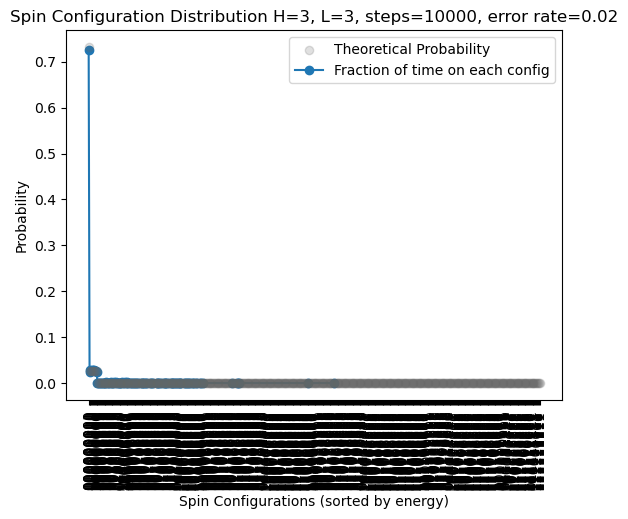

In [101]:
fig, ax = plt.subplots()

order = {lab: i for i, lab in enumerate(labels_sorted)}
x_all = np.arange(len(labels_sorted))
x_sub = np.array([order[lab] for lab in sorted_sublabels])
ax.scatter(x_all, P, color='0.4', label='Theoretical Probability', zorder=5, alpha =0.2)
ax.plot(x_sub, (np.array(time_frac1)[idx]/sum(time_frac1)),'-o', label = 'Fraction of time on each config')

# ax.plot(x_sub, np.array(sorted_subvalues)/duration,'o-',label = 'MC spin config counting')

ax.set( xlabel ='Spin Configurations (sorted by energy)',
       ylabel="Probability",
        title=f'Spin Configuration Distribution H={H}, L={L}, steps={duration}, error rate={error_rate}',
)
ax.set_xticks(x_all, labels_sorted, rotation=90)
# ax.set_ylim( 0, 0.2)

ax.legend()

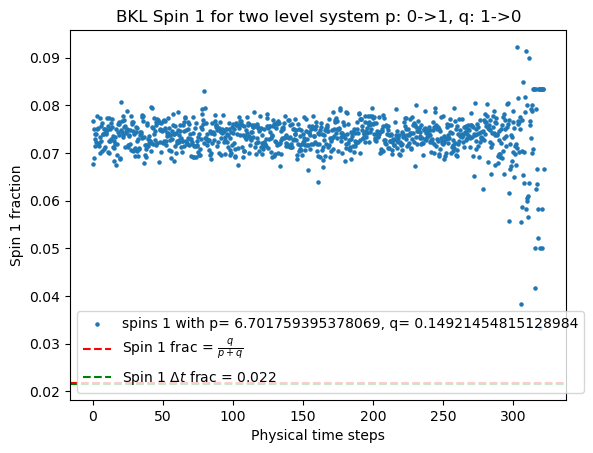

In [34]:
plt.scatter(mean_times, mean_mags,  label = f'spins 1 with p= {p}, q= {q}', s = 5)
plt.axhline(y=q/(p+q), color='r', linestyle='--', label =r'Spin 1 frac = $\frac{q}{p+q}$')
plt.axhline(y=mean_frac, color='g', linestyle='--', label =fr'Spin 1 $\Delta t$ frac = {mean_frac:.3f}')
plt.title('BKL Spin 1 for two level system p: 0->1, q: 1->0')
plt.xlabel('Physical time steps')
plt.ylabel('Spin 1 fraction')
plt.legend()
plt.show()

In [21]:
sum(frac)
np.sum(configs[spin_1])


np.int64(33)

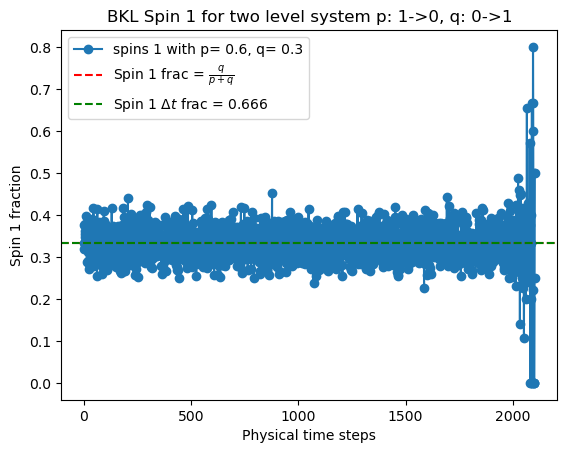

0.0007051199208248926


In [58]:
seeds = 200
steps = 2000
p = 0.6 # flip rate for 0->1
q = 0.3 # flip rate for 1->0
H = 1
L =1


lattice = np.zeros((H, L), dtype=int)
mag_lists = np.zeros((seeds, steps))
time_lists = np.zeros((seeds, steps))
fracs = np.zeros(seeds)
for seed in range(seeds):
    random.seed(seed)
    np.random.seed(seed)
    lattice, configs, time_list, labels = bkl(lattice, steps, p, q)
    mags = np.array([np.sum(np.abs(config)) for config in configs])/configs[0].size
    mag_lists[seed] = mags
    time_lists[seed] = np.cumsum(time_list)
    spin_1s = np.where(np.array(labels) == 0)[0]
    fracs[seed] = sum(np.array(time_list)[spin_1s])/sum(time_list)

#       time binning
mean_times, mean_mags = time_bin(time_lists, mag_lists)
mean_frac = np.mean(fracs)

#       plotting
plt.plot(mean_times, mean_mags, 'o-', label = f'spins 1 with p= {p}, q= {q}')
plt.axhline(y=q/(p+q), color='r', linestyle='--', label =r'Spin 1 frac = $\frac{q}{p+q}$')
plt.axhline(y=1-mean_frac, color='g', linestyle='--', label =fr'Spin 1 $\Delta t$ frac = {mean_frac:.3f}')
plt.title('BKL Spin 1 for two level system p: 1->0, q: 0->1')
plt.xlabel('Physical time steps')
plt.ylabel('Spin 1 fraction')
plt.legend()
plt.show()
print(p/(p+q) - mean_frac)

In [48]:
print(mean_frac)

0.16634511420828088


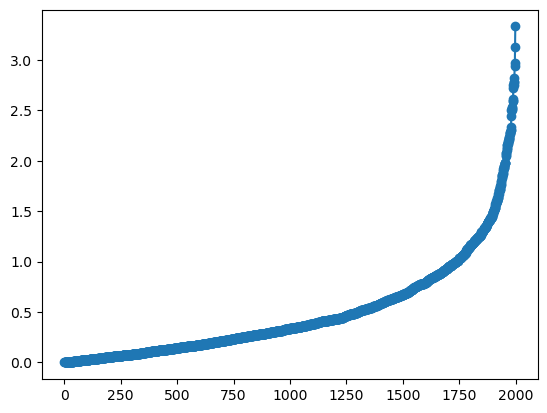

In [39]:
id = sorted(range(len(time_list)), key=lambda i: abs(time_list[i])) 
exp_dist = [time_list[i] for i in id]
plt.plot(exp_dist, 'o-')
# plt.plot([np.exp(i/1000) for i in range(2000)], 'r--')
# plt.xscale('log')
# plt.yscale('log')

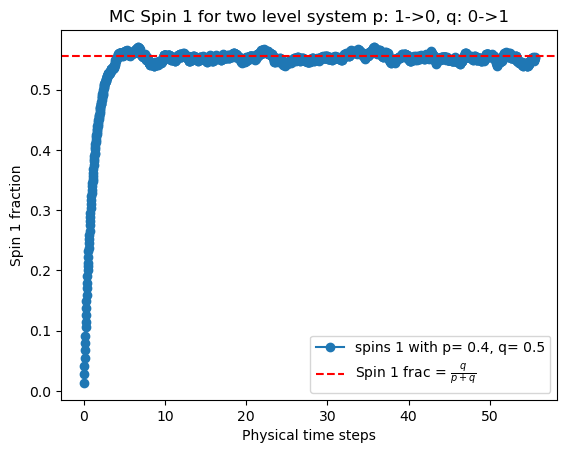

In [39]:
seeds = 200
steps = 2000
p = 0.4 # flip rate for 0->1
q = 0.5 # flip rate for 1->0
H = 6
L =6


lattice1 = np.zeros((H, L), dtype=int)
mag_lists1 = np.zeros((seeds, steps))
time_lists1 = np.zeros((seeds, steps))
for seed in range(seeds):
    random.seed(seed)
    np.random.seed(seed)
    lattice, configs, time_list = mc_spin_flip(lattice1, steps, p, q)
    mags = np.array([np.sum(np.abs(config)) for config in configs])/configs[0].size
    mag_lists1[seed] = mags
    time_lists1[seed] = np.cumsum(time_list)

#       time binning
mean_times1, mean_mags1 = time_bin(time_lists1, mag_lists1)

#       plotting
plt.plot(mean_times1, mean_mags1, 'o-', label = f'spins 1 with p= {p}, q= {q}')
plt.axhline(y=q/(p+q), color='r', linestyle='--', label =r'Spin 1 frac = $\frac{q}{p+q}$')
plt.title('MC Spin 1 for two level system p: 1->0, q: 0->1')
plt.xlabel('Physical time steps')
plt.ylabel('Spin 1 fraction')
plt.legend()
plt.show()

In [51]:
def correlation(spin_config: list):
    spin_conf = np.array(spin_config.copy())
    spin_conf = 1 - 2 * spin_conf  # Convert to -1, 1
    T, H, L = spin_conf.shape
    N = H * L
    # S_T = np.mean(spin_conf)
    # S_T = 1/2
    # correlation = []
    trajs = 200
    correlation = np.zeros((trajs,T-trajs))
    for t0 in range(trajs):
        S_T = np.full((H,L), np.mean(spin_conf[t0]))
        for tau in range(T-trajs):
            # For each tau, compute the correlation between t0 and t0+tau
            s0 = spin_conf[t0]        # shape (H, L)
            st = spin_conf[tau]  # shape (H, L)
            # Correlator: <S(t0) S(t0+tau)> - <S>^2, averaged over sites
            # Correlator: <(S(t0) - <S>) (S(t0+tau) - <S>)>, averaged over sites
            # corr = np.mean(s0 * st) - S_T ** 2
            corr = np.mean((((s0 -S_T)*(st - S_T))))  
            correlation[t0][tau] = corr
    
    return T-trajs, np.mean(correlation, axis=0)

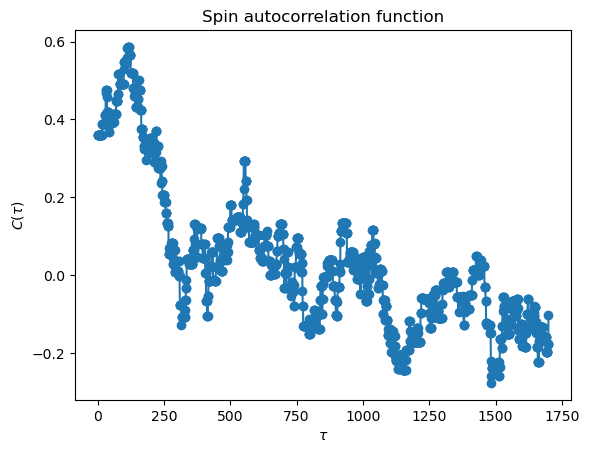

In [52]:
t, corr = correlation(configs[100:])
plt.plot(np.arange(t), corr, 'o-')
plt.title('Spin autocorrelation function')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$C(\tau)$')
plt.show()

